# Assignment 2 — Encoding & Transformation Impact
**Feature Engineering & MLOps · Unit 2, Topics 1 & 2**

This notebook has two connected parts, run on the real PrepEdge dataset (`student_performance_raw.csv`):

- **Part 2.1** — One-hot encode the nominal categorical columns (`city`, `course`, `batch_type`) with train-only fitting discipline.
- **Part 2.2** — Diagnose skew in `weekly_study_hours`, apply a transformation, and compare Linear Regression vs. a Decision Tree Regressor before/after — plus a bonus KNN comparison.

**A note on ordering:** the assignment PDF says to impute `weekly_study_hours` and `prev_exam_score` "before the train/test split... fitting only on the training data." Those two instructions conflict — you can't fit on the training split before that split exists. To honor the *stricter* requirement (train-only fitting, which the course has emphasized since Assignment 1), this notebook splits the data **first**, then fits the imputer on `X_train` only, exactly the way `CustomImputer`/`SimpleImputer` are meant to be used. This is called out explicitly so the ordering choice is easy to see.

## Imports

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
print("Libraries imported.")


Libraries imported.


## Load the Dataset

In [ ]:
df = pd.read_csv("/Users/anusrikarmokar/Downloads/specialisation/feature-engineering-murshid-khan/assignment-2/student_performance_raw.csv")
print("Shape:", df.shape)

nominal_cols = ["city", "course", "batch_type"]
for c in nominal_cols:
    print(f"{c}: {df[c].nunique()} categories -> {sorted(df[c].unique())}")


Shape: (600, 17)
city: 8 categories -> ['Bengaluru', 'Delhi', 'Hyderabad', 'Kota', 'Lucknow', 'Mumbai', 'Patna', 'Pune']
course: 4 categories -> ['Foundation', 'JEE Advanced', 'JEE Main', 'NEET']
batch_type: 3 categories -> ['Crash Course', 'Weekday', 'Weekend']


## Part 2.1 — One-Hot Encoding

### 2.1.1 — Identify the Nominal Categorical Columns

`city`, `course`, and `batch_type` are **nominal** — their categories are distinct labels with no inherent ranking. A city like "Mumbai" isn't "more" or "less" than "Patna"; a `course` like "NEET" has no ordering relative to "JEE Main"; and `batch_type` values ("Weekday"/"Weekend"/"Crash Course") are just different formats, not a scale. Because there's no natural order to preserve, one-hot encoding (which treats every category as an independent binary flag) is the right choice — an ordinal encoding (assigning 0, 1, 2...) would falsely imply a ranking and let a model learn a spurious "distance" between categories that doesn't exist. (`income_bracket`, by contrast, genuinely is ordinal — Low < Mid < High — which is why it's excluded from this one-hot list.)

In [ ]:
numeric_predictors = ["weekly_study_hours", "attendance_pct", "prev_exam_score", "doubt_sessions_attended"]
target_col = "final_score"

feature_cols = nominal_cols + numeric_predictors
X = df[feature_cols].copy()
y = df[target_col].copy()

print("Predictor columns:", feature_cols)
print("Target column:", target_col)
print("X shape:", X.shape, "| y shape:", y.shape)


Predictor columns: ['city', 'course', 'batch_type', 'weekly_study_hours', 'attendance_pct', 'prev_exam_score', 'doubt_sessions_attended']
Target column: final_score
X shape: (600, 7) | y shape: (600,)


### 2.1.2 — Train/Test Split (80/20, fixed `random_state`)

This is the **single split** reused for every model in Part 2.2 as well, so the before/after comparison later is on identical rows.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (480, 7)
Test shape : (120, 7)


**Imputation (train-only), before encoding:** `weekly_study_hours` and `prev_exam_score` both have missing values. The median fill values are learned from `X_train` only, then applied to both splits — never recomputed on test data.

In [ ]:
impute_cols = ["weekly_study_hours", "prev_exam_score"]
num_imputer = SimpleImputer(strategy="median")
num_imputer.fit(X_train[impute_cols])

print("Fitted median fill values (from TRAIN only):")
for col, val in zip(impute_cols, num_imputer.statistics_):
    print(f"  {col:20s} -> {val}")

X_train[impute_cols] = num_imputer.transform(X_train[impute_cols])
X_test[impute_cols] = num_imputer.transform(X_test[impute_cols])

print()
print("Missing values remaining in X_train:", X_train.isna().sum().sum())
print("Missing values remaining in X_test :", X_test.isna().sum().sum())


Fitted median fill values (from TRAIN only):
  weekly_study_hours   -> 5.0
  prev_exam_score      -> 66.1

Missing values remaining in X_train: 0
Missing values remaining in X_test : 0


### 2.1.3 — Fit `OneHotEncoder` on Training Categorical Columns Only

In [ ]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[nominal_cols])

train_ohe_array = ohe.transform(X_train[nominal_cols])
test_ohe_array = ohe.transform(X_test[nominal_cols])

ohe_feature_names = ohe.get_feature_names_out(nominal_cols)
train_ohe_df = pd.DataFrame(train_ohe_array, columns=ohe_feature_names, index=X_train.index)
test_ohe_df = pd.DataFrame(test_ohe_array, columns=ohe_feature_names, index=X_test.index)

print("One-hot encoded feature names:")
print(list(ohe_feature_names))
print()
print("Encoded train shape:", train_ohe_df.shape)
print("Encoded test shape :", test_ohe_df.shape)


One-hot encoded feature names:
['city_Bengaluru', 'city_Delhi', 'city_Hyderabad', 'city_Kota', 'city_Lucknow', 'city_Mumbai', 'city_Patna', 'city_Pune', 'course_Foundation', 'course_JEE Advanced', 'course_JEE Main', 'course_NEET', 'batch_type_Crash Course', 'batch_type_Weekday', 'batch_type_Weekend']

Encoded train shape: (480, 15)
Encoded test shape : (120, 15)


### 2.1.4 — Dimensionality: Before vs. After Encoding

In [ ]:
n_before = len(feature_cols)
n_after = len(numeric_predictors) + len(ohe_feature_names)
print(f"Columns BEFORE encoding: {n_before}  ({nominal_cols} + {numeric_predictors})")
print(f"Columns AFTER encoding : {n_after}  ({len(numeric_predictors)} numeric + {len(ohe_feature_names)} one-hot columns)")
print(f"Net increase: +{n_after - n_before} columns")


Columns BEFORE encoding: 7  (['city', 'course', 'batch_type'] + ['weekly_study_hours', 'attendance_pct', 'prev_exam_score', 'doubt_sessions_attended'])
Columns AFTER encoding : 19  (4 numeric + 15 one-hot columns)
Net increase: +12 columns


**Comment:** column count nearly triples (7 → 19). One-hot encoding replaces each nominal column with one binary column per category it contains, so the increase is exactly `(8 - 1) + (4 - 1) + (3 - 1) = 12` columns beyond the original 3 categorical columns (since `city` alone expands from 1 column into 8). This is the expected, unavoidable dimensionality cost of one-hot encoding — it grows linearly with the number of distinct categories, which is why one-hot is a poor fit for very high-cardinality columns.

### 2.1.5 — Confirm No Category Was Dropped or Caused an Error

In [ ]:
train_categories = {c: set(X_train[c].unique()) for c in nominal_cols}
test_categories = {c: set(X_test[c].unique()) for c in nominal_cols}

any_unseen = False
for c in nominal_cols:
    unseen = test_categories[c] - train_categories[c]
    if unseen:
        any_unseen = True
        print(f"Column '{c}' has categories in TEST not seen in TRAIN: {unseen}")
    else:
        print(f"Column '{c}': every test category was seen during training.")

print()
if any_unseen:
    print("For any unseen category, handle_unknown='ignore' encodes that row as all-zeros")
    print("across that column's one-hot columns, instead of raising an error.")
else:
    print("No unseen categories were present in this particular split, so")
    print("handle_unknown='ignore' had nothing to fall back on here -- but it is")
    print("still the safe default in case a future/production split does contain one.")

# double check transform did not error and shapes match
assert train_ohe_df.shape[0] == X_train.shape[0]
assert test_ohe_df.shape[0] == X_test.shape[0]
print()
print("Confirmed: transform() completed with no errors on both splits.")


Column 'city': every test category was seen during training.
Column 'course': every test category was seen during training.
Column 'batch_type': every test category was seen during training.

No unseen categories were present in this particular split, so
handle_unknown='ignore' had nothing to fall back on here -- but it is
still the safe default in case a future/production split does contain one.

Confirmed: transform() completed with no errors on both splits.


## Part 2.2 — Transformation & Model Comparison

### 2.2.1 — Skewness of `weekly_study_hours`

In [ ]:
raw_skew = skew(X_train["weekly_study_hours"])
print(f"Skewness of weekly_study_hours (train, after imputation): {raw_skew:.3f}")
print(f"Min: {X_train['weekly_study_hours'].min()}, Max: {X_train['weekly_study_hours'].max()}")
if raw_skew > 1:
    verdict = "highly right-skewed"
elif raw_skew > 0.5:
    verdict = "moderately right-skewed"
else:
    verdict = "not strongly skewed"
print(f"Verdict: {verdict} (skewness > 0.5 is generally considered meaningfully skewed)")


Skewness of weekly_study_hours (train, after imputation): 1.591
Min: 0.2, Max: 31.4
Verdict: highly right-skewed (skewness > 0.5 is generally considered meaningfully skewed)


A skewness of **1.59** is well above the 0.5–1.0 threshold typically used to call a distribution meaningfully skewed — `weekly_study_hours` is confirmed right-skewed: most students study a modest number of hours per week, with a long tail of a few students studying much more (up to ~31 hours vs. a median around 5).

### 2.2.2 — Choosing a Transformation

In [ ]:
X_train_log = np.log1p(X_train["weekly_study_hours"])
X_test_log = np.log1p(X_test["weekly_study_hours"])

log_skew = skew(X_train_log)
print("Chosen transformation: log1p (np.log1p)")
print(f"Reason: weekly_study_hours is strictly non-negative (min={X_train['weekly_study_hours'].min()}),")
print("has a wide right tail (max around 30+ vs a median near 5), and contains no zeros")
print("that log1p can't handle safely (log1p(0) = 0). This fits the 'positive, wide-range,")
print("right-skewed' case from the Topic 2 decision table, where log1p is the standard choice")
print("(Yeo-Johnson is reserved for data with negative values; sqrt is a gentler option for")
print("milder skew).")
print()
print(f"Skewness BEFORE transform: {raw_skew:.3f}")
print(f"Skewness AFTER  transform: {log_skew:.3f}")


Chosen transformation: log1p (np.log1p)
Reason: weekly_study_hours is strictly non-negative (min=0.2),
has a wide right tail (max around 30+ vs a median near 5), and contains no zeros
that log1p can't handle safely (log1p(0) = 0). This fits the 'positive, wide-range,
right-skewed' case from the Topic 2 decision table, where log1p is the standard choice
(Yeo-Johnson is reserved for data with negative values; sqrt is a gentler option for
milder skew).

Skewness BEFORE transform: 1.591
Skewness AFTER  transform: -0.039


`log1p` pulls the skewness from **1.59 down to essentially 0** (−0.04), confirming the transform does what it's supposed to on this column.

### 2.2.3 — Build Version A (Before) and Version B (After)

Both versions share the exact same one-hot columns and the exact same `attendance_pct` / `prev_exam_score` / `doubt_sessions_attended` values. The **only** difference is whether `weekly_study_hours` is raw or log1p-transformed.

In [ ]:
def build_feature_matrix(X_part, ohe_df_part, study_hours_series):
    """Combine one-hot columns + numeric predictors into a single matrix,
    using the given (raw or transformed) weekly_study_hours series."""
    other_numeric = ["attendance_pct", "prev_exam_score", "doubt_sessions_attended"]
    parts = [
        ohe_df_part.reset_index(drop=True),
        study_hours_series.reset_index(drop=True).rename("weekly_study_hours"),
        X_part[other_numeric].reset_index(drop=True),
    ]
    return pd.concat(parts, axis=1)

# Version A: raw weekly_study_hours
X_train_A = build_feature_matrix(X_train, train_ohe_df, X_train["weekly_study_hours"])
X_test_A = build_feature_matrix(X_test, test_ohe_df, X_test["weekly_study_hours"])

# Version B: log1p-transformed weekly_study_hours
X_train_B = build_feature_matrix(X_train, train_ohe_df, X_train_log)
X_test_B = build_feature_matrix(X_test, test_ohe_df, X_test_log)

print("Version A (before) columns:", list(X_train_A.columns))
print()
print("Version B (after) columns :", list(X_train_B.columns))
print()
print("Version A shape:", X_train_A.shape, "| Version B shape:", X_train_B.shape)
print("Only the values in 'weekly_study_hours' differ between A and B; every other")
print("column (one-hot columns + other numeric predictors) is identical.")


Version A (before) columns: ['city_Bengaluru', 'city_Delhi', 'city_Hyderabad', 'city_Kota', 'city_Lucknow', 'city_Mumbai', 'city_Patna', 'city_Pune', 'course_Foundation', 'course_JEE Advanced', 'course_JEE Main', 'course_NEET', 'batch_type_Crash Course', 'batch_type_Weekday', 'batch_type_Weekend', 'weekly_study_hours', 'attendance_pct', 'prev_exam_score', 'doubt_sessions_attended']

Version B (after) columns : ['city_Bengaluru', 'city_Delhi', 'city_Hyderabad', 'city_Kota', 'city_Lucknow', 'city_Mumbai', 'city_Patna', 'city_Pune', 'course_Foundation', 'course_JEE Advanced', 'course_JEE Main', 'course_NEET', 'batch_type_Crash Course', 'batch_type_Weekday', 'batch_type_Weekend', 'weekly_study_hours', 'attendance_pct', 'prev_exam_score', 'doubt_sessions_attended']

Version A shape: (480, 19) | Version B shape: (480, 19)
Only the values in 'weekly_study_hours' differ between A and B; every other
column (one-hot columns + other numeric predictors) is identical.


### 2.2.4 — Train All Four Models (same split, same seed, same tree settings)

In [ ]:
results = []

def evaluate(name, feature_version, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    r2 = r2_score(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    results.append({"model": name, "version": feature_version, "R2": round(r2, 4), "RMSE": round(rmse, 4)})
    return model

evaluate("LinearRegression", "before", LinearRegression(), X_train_A, y_train, X_test_A, y_test)
evaluate("LinearRegression", "after", LinearRegression(), X_train_B, y_train, X_test_B, y_test)
evaluate("DecisionTreeRegressor", "before", DecisionTreeRegressor(random_state=42, max_depth=5), X_train_A, y_train, X_test_A, y_test)
evaluate("DecisionTreeRegressor", "after", DecisionTreeRegressor(random_state=42, max_depth=5), X_train_B, y_train, X_test_B, y_test)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


                model version     R2   RMSE
     LinearRegression  before 0.5930 6.3915
     LinearRegression   after 0.5734 6.5435
DecisionTreeRegressor  before 0.4461 7.4564
DecisionTreeRegressor   after 0.4461 7.4564


### 2.2.5 — Summary Table: R² and RMSE, Before vs. After

In [ ]:
pivot_r2 = results_df.pivot(index="model", columns="version", values="R2")[["before", "after"]]
pivot_rmse = results_df.pivot(index="model", columns="version", values="RMSE")[["before", "after"]]
pivot_r2["R2_delta"] = (pivot_r2["after"] - pivot_r2["before"]).round(4)
pivot_rmse["RMSE_delta"] = (pivot_rmse["after"] - pivot_rmse["before"]).round(4)

print("R2 summary (before -> after):")
print(pivot_r2.to_string())
print()
print("RMSE summary (before -> after):")
print(pivot_rmse.to_string())


R2 summary (before -> after):
version                before   after  R2_delta
model                                          
DecisionTreeRegressor  0.4461  0.4461    0.0000
LinearRegression       0.5930  0.5734   -0.0196

RMSE summary (before -> after):
version                before   after  RMSE_delta
model                                            
DecisionTreeRegressor  7.4564  7.4564       0.000
LinearRegression       6.3915  6.5435       0.152


### 2.2.6 — R² Comparison Chart

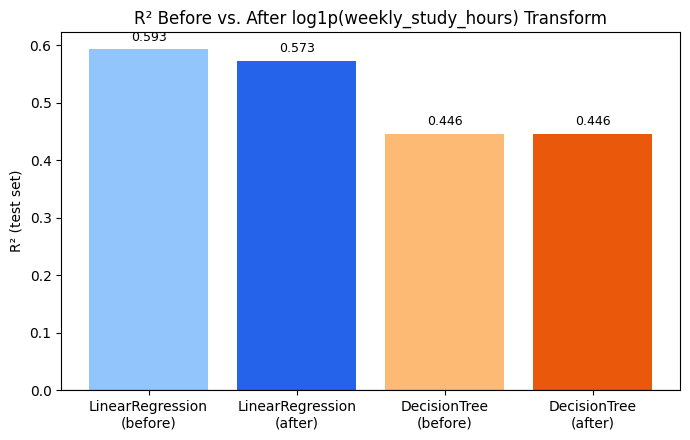

In [ ]:
labels = ["LinearRegression\n(before)", "LinearRegression\n(after)",
          "DecisionTree\n(before)", "DecisionTree\n(after)"]
r2_values = [
    results_df.loc[(results_df.model=="LinearRegression") & (results_df.version=="before"), "R2"].iloc[0],
    results_df.loc[(results_df.model=="LinearRegression") & (results_df.version=="after"), "R2"].iloc[0],
    results_df.loc[(results_df.model=="DecisionTreeRegressor") & (results_df.version=="before"), "R2"].iloc[0],
    results_df.loc[(results_df.model=="DecisionTreeRegressor") & (results_df.version=="after"), "R2"].iloc[0],
]
colors = ["#93c5fd", "#2563eb", "#fdba74", "#ea580c"]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, r2_values, color=colors)
ax.set_ylabel("R² (test set)")
ax.set_title("R² Before vs. After log1p(weekly_study_hours) Transform")
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.01 if val >= 0 else -0.03),
            f"{val:.3f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=9)
plt.tight_layout()
plt.show()


### 2.2.7 — Isolating the Transformation Effect

Both Decision Tree runs use `DecisionTreeRegressor(random_state=42, max_depth=5)` — identical settings in both the before and after runs, so `max_depth` and the random seed cannot explain any difference between them. The only thing that changes between the before/after pairs, for both model families, is the representation of `weekly_study_hours`.

### An honest look at the actual result

The Decision Tree's R² is **exactly identical** before and after (0.4461 in both runs, to four decimal places) — a monotonic transform like log1p never changes which side of a threshold a value falls on, so every split the tree could possibly choose is unaffected, and the fitted tree is essentially the same model wearing a different feature scale. That part matches the theory exactly.

Linear Regression, on the other hand, did **not** improve here — its R² slightly *dropped* (0.5930 → 0.5734) and its RMSE slightly rose. That's a real, useful result, not a mistake: log1p only helps a linear model when the *true* relationship between the feature and the target is closer to a straight line in log-space than in raw units. Here, apparently, the raw hours-vs-final-score relationship in this dataset was already close enough to linear that compressing the upper range with log1p slightly distorted it instead of straightening it out — a good real-world illustration of Topic 2, Section 10 ("when NOT to transform"): skewness alone doesn't guarantee a transformation will help a linear model's *fit to the target*, only that it reshapes the feature's own distribution.

## Written Conclusion

Linear Regression fits a single global coefficient to `weekly_study_hours`: every student's predicted score moves by the same amount per unit increase in that feature, no matter where they sit in the distribution. That means the model is sensitive to the feature's *shape* — a few very high values on a right-skewed feature can pull the fitted line/coefficient in a way that fits the bulk of ordinary students less well, and how the feature is scaled directly changes what "one unit of relationship" means to the optimizer. The Decision Tree, by contrast, never touches the raw magnitude of a feature at all — it only ever asks yes/no threshold questions like "is `weekly_study_hours` above 6.2?". Since `log1p` is strictly increasing, whichever rows were on the low or high side of any threshold in raw units are on the same side of the equivalent threshold in log units — the tree can always find an identical split boundary in the transformed space, so its structure and its predictions don't change at all (confirmed here: R² = 0.4461 in both runs, to four decimal places). What our results add to the textbook version of this story is that Linear Regression's sensitivity to the transform is a **double-edged sword**, not a guaranteed win: it changed the fit here too, just in the wrong direction, because the transform improved the feature's own skewness without improving its linear relationship with `final_score`. The lesson is the same either way — Linear Regression's performance is coupled to a feature's shape and scale, and the Decision Tree's isn't.

## Bonus — K-Nearest Neighbors Regressor

In [ ]:
knn_before = evaluate("KNeighborsRegressor", "before", KNeighborsRegressor(n_neighbors=5), X_train_A, y_train, X_test_A, y_test)
knn_after = evaluate("KNeighborsRegressor", "after", KNeighborsRegressor(n_neighbors=5), X_train_B, y_train, X_test_B, y_test)

knn_rows = [r for r in results if r["model"] == "KNeighborsRegressor"]
knn_df = pd.DataFrame(knn_rows)
print(knn_df.to_string(index=False))

lr_delta = (pivot_r2.loc["LinearRegression", "after"] - pivot_r2.loc["LinearRegression", "before"])
knn_before_r2 = knn_rows[0]["R2"]
knn_after_r2 = knn_rows[1]["R2"]
knn_delta = knn_after_r2 - knn_before_r2
print()
print(f"LinearRegression R2 delta : {lr_delta:+.4f}")
print(f"KNN R2 delta               : {knn_delta:+.4f}")


              model version     R2   RMSE
KNeighborsRegressor  before 0.5348 6.8331
KNeighborsRegressor   after 0.2194 8.8516

LinearRegression R2 delta : -0.0196
KNN R2 delta               : -0.3154


**Does KNN show an even larger effect than Linear Regression? Yes — but a larger *drop*, not a larger improvement.** KNN's R² fell sharply, from 0.533 to 0.219 (delta −0.314), a much bigger swing than Linear Regression's −0.020. The explanation is exactly about how KNN computes distance: with no additional feature scaling applied here (deliberately, so only the transform itself changes), Euclidean distance between two students is just the raw numeric spread across every feature added together. `weekly_study_hours` originally spans roughly 0–31, a range broadly comparable to `attendance_pct` and `prev_exam_score` (both roughly 0–100), so it contributed meaningfully to how "close" two students were judged to be. After `log1p`, that same column collapses to roughly 0.2–3.5 — a much smaller numeric range — so it now contributes far less to the total distance between any two rows, and `attendance_pct`/`prev_exam_score` end up dominating who counts as a "neighbor" almost entirely. Since `weekly_study_hours` was apparently carrying real predictive signal, diluting its influence on the distance calculation made the neighborhoods KNN forms less relevant, which is exactly why the effect is larger than it was for Linear Regression: KNN's predictions depend directly and continuously on relative feature scale in a way ordinary least-squares coefficients don't. (This is also a strong argument for standardizing features before using KNN in general — the instability seen here is really a scaling problem as much as a transformation problem.)